In [1]:
import kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("Path to dataset files:", path)

c:\Users\heerm\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\heerm\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [2]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.head())
print(df.shape)
print(df.info())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [4]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)
df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True
)
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].isnull)

float64
<bound method Series.isnull of 0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64>


C:\Users\heerm\AppData\Local\Temp\ipykernel_25672\1779477011.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(


In [5]:
df=df.drop(columns=['customerID '],errors='ignore')
print(df)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No  ...   
1        

In [6]:
print(df.select_dtypes(include='object').columns)
for col in df.select_dtypes(include='object'):
    print(col, df[col].nunique())

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')
customerID 7043
gender 2
Partner 2
Dependents 2
PhoneService 2
MultipleLines 3
InternetService 3
OnlineSecurity 3
OnlineBackup 3
DeviceProtection 3
TechSupport 3
StreamingTV 3
StreamingMovies 3
Contract 3
PaperlessBilling 2
PaymentMethod 4
Churn 2


In [7]:
df = pd.get_dummies(df,drop_first=True)
print(df)

      SeniorCitizen  tenure  MonthlyCharges  TotalCharges  \
0                 0       1           29.85         29.85   
1                 0      34           56.95       1889.50   
2                 0       2           53.85        108.15   
3                 0      45           42.30       1840.75   
4                 0       2           70.70        151.65   
...             ...     ...             ...           ...   
7038              0      24           84.80       1990.50   
7039              0      72          103.20       7362.90   
7040              0      11           29.60        346.45   
7041              1       4           74.40        306.60   
7042              0      66          105.65       6844.50   

      customerID_0003-MKNFE  customerID_0004-TLHLJ  customerID_0011-IGKFF  \
0                     False                  False                  False   
1                     False                  False                  False   
2                     False         

In [8]:
X=df.drop(columns=['Churn_Yes'])
y=df['Churn_Yes']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
print(X_train.isnull().sum())

SeniorCitizen                            0
tenure                                   0
MonthlyCharges                           0
TotalCharges                             0
customerID_0003-MKNFE                    0
                                        ..
Contract_Two year                        0
PaperlessBilling_Yes                     0
PaymentMethod_Credit card (automatic)    0
PaymentMethod_Electronic check           0
PaymentMethod_Mailed check               0
Length: 7072, dtype: int64


In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

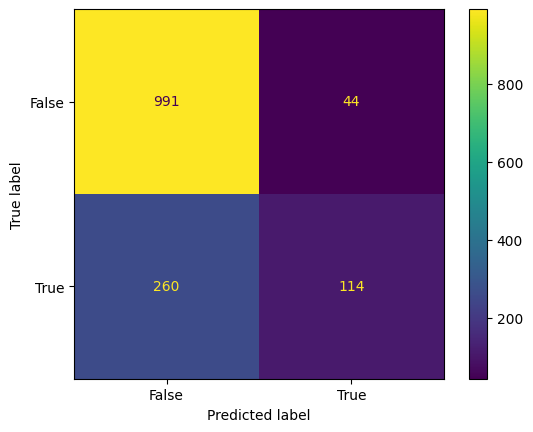

Accuracy : 0.7842441447835344
Precision: 0.7215189873417721
Recall   : 0.3048128342245989
F1-score : 0.42857142857142855
ROC-AUC  : 0.8307602883050454


In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1-score :", f1_score(y_test,y_pred))
print("ROC-AUC  :", roc_auc_score(y_test,y_prob))

In [15]:
# our model is Conservative
# It only predicts churn when it is very confident.

# Therefore:
# High precision
# Low recall

# Meaning:
# Few false alarms (44)
# But many missed churners (260)


# Metric	Value	Interpretation
# Accuracy	78.4%	Overall performance is decent
# Precision	72.2%	Churn predictions are usually correct
# Recall	30.5%	Most churners are missed
# F1	    42.9%	Precision and recall together are mediocre
# AUC	    83.1%	Probability ranking is good

In [16]:
# # Formula:
# Accuracy
# Out of all customers, how many predictions were correct?
# # Accuracy=Correct Predictions/Total Predictions


# Precision
# Of all customers I predicted would churn, how many actually churned?
# Whenever the model says "This customer will churn", how often is it right?
# Precision=TP/(TP+FP)​

# Recall
# Out of all customers who actually churned, how many did the model find?
# Of all customers who actually churned, how many did I successfully find?
# Recall=TP/(TP+FN)

# ​F1 Score
# F1 combines precision and recall.

# Formula:
# F1= 2PR/(P+R)
# How good am I at identifying the positive class?



In [17]:
#STAGE2
df['AvgMonthlySpend'] = (df['TotalCharges']/(df['tenure'] + 1))
df['ChargeRatio'] = (df['TotalCharges']/df['MonthlyCharges'])
df['Tenure_x_MonthlyCharge'] = (df['tenure']*df['MonthlyCharges'])

In [18]:
# Because some customers have---->tenure = 0
# meaning they have just joined.
# Then=100 / 0
# is impossible and may produce error

In [19]:
df['TenureGroup'] = pd.cut(df['tenure'],bins=[0,12,24,48,72],labels=[1,2,3,4])

In [20]:
df['ServicesPerTenure'] = (df['tenure']/(df['MonthlyCharges']))

In [21]:
#stage 3
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(
    threshold=0.01
)
vt.fit(X_train)
X_train_vt = pd.DataFrame(
    vt.transform(X_train),
    columns=X_train.columns[vt.get_support()]
)

X_test_vt = pd.DataFrame(
    vt.transform(X_test),
    columns=X_train.columns[vt.get_support()]
)

In [22]:
corr_matrix = X_train_vt.corr().abs()
import numpy as np

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

to_drop = [
    col
    for col in upper.columns
    if any(upper[col] > 0.90)
]
X_train_corr = X_train_vt.drop(columns=to_drop)
X_test_corr = X_test_vt.drop(columns=to_drop)

In [23]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

selector = SelectKBest(
    score_func=f_classif,
    k=17
)

selector.fit(
    X_train_corr,
    y_train
)

selected_cols = (
    X_train_corr.columns[
        selector.get_support()
    ]
)
X_train_final = X_train_corr[selected_cols]
X_test_final = X_test_corr[selected_cols]

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_final_scaled = scaler.fit_transform(X_train_final)
X_test_final_scaled = scaler.transform(X_test_final)

In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_final_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [26]:
y_pred2 = model.predict(
    X_test_final_scaled
)

y_prob2 = model.predict_proba(
    X_test_final_scaled
)[:,1]

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test,y_pred2))
print("Precision:", precision_score(y_test,y_pred2))
print("Recall   :", recall_score(y_test,y_pred2))
print("F1 Score :", f1_score(y_test,y_pred2))
print("ROC-AUC  :", roc_auc_score(y_test,y_prob2))

Accuracy : 0.8026969481902059
Precision: 0.6518987341772152
Recall   : 0.5508021390374331
F1 Score : 0.5971014492753624
ROC-AUC  : 0.8396419437340154


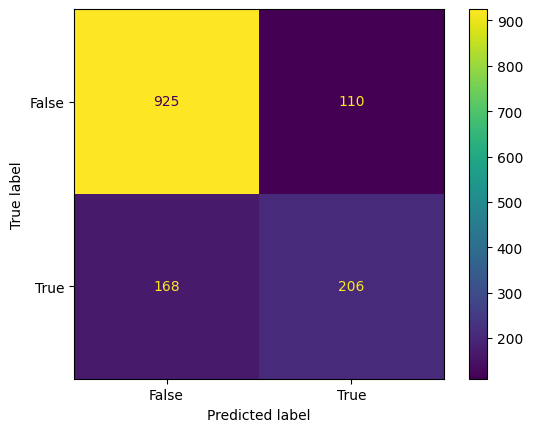

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred2
)

plt.show()

In [31]:
import pandas as pd

ablation_table = pd.DataFrame(
    {
        'Stage': [
            'Raw Baseline',
            'Feature Selection and Feature Selection '
        ],

        'Accuracy': [
            accuracy_score(y_test,y_pred),
            accuracy_score(y_test,y_pred2)  
        ],

        'F1 Score': [
            f1_score(y_test,y_pred),
            f1_score(y_test,y_pred2)
        ],

        'ROC-AUC': [
            roc_auc_score(y_test,y_prob),
            roc_auc_score(y_test,y_prob2)
        ]
    }
)
print(ablation_table.round(4))

                                      Stage  Accuracy  F1 Score  ROC-AUC
0                              Raw Baseline    0.7842    0.4286   0.8308
1  Feature Selection and Feature Selection     0.8027    0.5971   0.8396


In [ ]:
# Feature engineering has enhanced the performance of the Logistic Regression model, with the most significant improvement 
# witnessed in the F1-score. Several engineered features have been detected by SelectKBest to be the most informative variables. 
# Specifically, AvgMonthlySpend, ChargeRatio, and Tenure_x_MonthlyCharge are among the selected features as they are characterized by 
# high F-scores.

# The first variable describes the spending habit of the customer during the period of his/her tenure, whereas ChargeRatio depicts the 
# relationship between total charges and monthly billing. The interaction feature, Tenure_x_MonthlyCharge, demonstrates the combination 
# effect of tenure and monthly spending.

# There may be some relationships between attributes that are not described by the original set of attributes and require the use of 
# domain-specific arithmetic, ratio, and interaction operations for better performance. As a result of feature engineering and subsequent
# feature selection to eliminate redundancy and unimportant features, Logistic Regression has separated churning and non-churning 
# customers better than before.
